# Unemployment Analysis in India — Regional & Temporal Trends Through the COVID-19 Shock

**Track:** Data Science &nbsp;|&nbsp; **Task:** 2 — Unemployment Analysis with Python
**Author:** **Youssef Laaroussi** (Master in Data Science & Artificial Intelligence) &nbsp;|&nbsp; **Program:** Oasis Infobyte SIP

---

## Objective

Explore India's state-level unemployment dynamics to uncover regional disparities and temporal trends. The primary analytical objective is to quantify and statistically validate the macroeconomic impact of the COVID-19 nationwide lockdown (April–June 2020) on employment and labor force participation using rigorous exploratory and inferential data techniques.


<a id='1'></a>
## 1. Environment Setup & Imports

In [2]:
# Core data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display


# Statistical test for the pre/post-COVID comparison
from scipy.stats import mannwhitneyu

# Reproducibility & display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100

print("Libraries imported successfully.")


Libraries imported successfully.


<a id='2'></a>
## 2. Data Sourcing & Ingestion

The dataset captures monthly unemployment rates, employment headcounts, and labor participation rates across 28 Indian states and union territories from May 2019 to June 2020, disaggregated by Rural and Urban classifications (Source: Centre for Monitoring Indian Economy / Kaggle).


In [4]:
DATA_PATH = 'Unemployment in India.csv'

raw_df = pd.read_csv(DATA_PATH)
print(f"Loaded '{DATA_PATH}' successfully: {raw_df.shape[0]} rows x {raw_df.shape[1]} columns.")


Loaded 'Unemployment in India.csv' successfully: 768 rows x 7 columns.


<a id='3'></a>
## 3. Data Preparation

<a id='31'></a>
### 3.1 Shape Inspection



In [6]:
# Checklist item: shape inspection
print(f"Shape: {raw_df.shape[0]} rows x {raw_df.shape[1]} columns")
print("\nColumn names (note the stray leading spaces — a real messy-data artifact"
      " we will clean in Section 3.3):")
print(list(raw_df.columns))


Shape: 768 rows x 7 columns

Column names (note the stray leading spaces — a real messy-data artifact we will clean in Section 3.3):
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


<a id='32'></a>
### 3.2 Null Value Check



In [8]:
# Checklist item: null value check (on the RAW, uncleaned data)
print("Missing values per column (raw data):")
print(raw_df.isnull().sum())
print(f"\nTotal fully-empty rows: {raw_df.isnull().all(axis=1).sum()}")


Missing values per column (raw data):
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Total fully-empty rows: 28


**Observation:** every column has exactly the same number of nulls (28),
and those nulls are entirely explained by fully-blank trailing rows at the
bottom of the CSV file (a common export artifact from Kaggle CSVs) — not by
scattered missing individual values. We confirm this below before deciding how
to handle them.

In [10]:
blank_rows = raw_df[raw_df.isnull().all(axis=1)]
print(f"Confirmed: {len(blank_rows)} rows are 100% empty across all columns.")
print("These will be dropped, not imputed, since there is no data to impute — "
      "they are empty file padding, not missing measurements.")


Confirmed: 28 rows are 100% empty across all columns.
These will be dropped, not imputed, since there is no data to impute — they are empty file padding, not missing measurements.


<a id='33'></a>
### 3.3 Type Conversion & Cleaning


Three real data-quality issues need fixing before analysis:
1. Column names have leading whitespace (`" Date"`, `" Frequency"`, etc.).
2. String/categorical values (`Region`, `Area`) may also carry stray
   whitespace, which would otherwise silently break `groupby` operations
   (`"Delhi"` and `"Delhi "` would be treated as two different states).
3. `Date` is loaded as plain text, not a real datetime — it needs explicit
   type conversion to support time-series operations like `resample()`.

In [12]:
df = raw_df.copy()

# Checklist item: type conversion (step 1) -- clean column names
df.columns = [c.strip() for c in df.columns]

# Checklist item: type conversion (step 2) -- drop the fully-empty padding rows
df = df.dropna(how="all").reset_index(drop=True)

# Checklist item: type conversion (step 3) -- strip whitespace from ALL string
# columns, including Date, which also carries a leading space (" 31-05-2019")
# that would otherwise break datetime parsing below.
for col in ["Region", "Date", "Frequency", "Area"]:
    df[col] = df[col].astype(str).str.strip()

# Checklist item: type conversion (step 4) -- convert Date from text to real datetime
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

# Checklist item: type conversion (step 5) -- convert low-cardinality text columns to 'category'
# dtype, which is both more memory-efficient and semantically correct (these
# are categorical labels, not free text).
for col in ["Region", "Frequency", "Area"]:
    df[col] = df[col].astype("category")

print("Cleaning complete.")
df.dtypes


Cleaning complete.


<a id='34'></a>
### 3.4 Post-Cleaning Verification

Re-running the same shape and null checks confirms the cleaning worked as
intended.

In [14]:
print(f"Shape after cleaning: {df.shape[0]} rows x {df.shape[1]} columns "
      f"(was {raw_df.shape[0]} rows before)")
print("\nMissing values after cleaning:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nDate range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Number of states/UTs covered: {df['Region'].nunique()}")
print(f"Area categories: {list(df['Area'].cat.categories)}")

df.describe()


Shape after cleaning: 740 rows x 7 columns (was 768 rows before)

Missing values after cleaning:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

Duplicate rows: 0

Date range: 2019-05-31 to 2020-06-30
Number of states/UTs covered: 28
Area categories: ['Rural', 'Urban']


**Observation:** cleaning removed exactly the 28 blank padding rows and
nothing else — row count dropped from 768 to 740, with zero remaining nulls
and zero duplicate rows. The dataset now spans **May 2019 to June 2020**
across **28 states/union territories**, split by **Rural/Urban** area, which
is exactly the shape needed for the regional, temporal, and pre/post-COVID
analysis that follows.

<a id='35'></a>
### 3.5 Choosing the Pre/Post-COVID Cutoff, Backed by Data

Rather than assuming the lockdown announcement date (24–25 March 2020) is
where the *data* shows a shift, we check the actual national monthly average
first. India's nationwide lockdown began in the **last week of March**, so a
monthly average for March 2020 mostly reflects pre-lockdown conditions, and
the real shock should only be fully visible starting **April 2020**.

In [17]:
national_monthly = df.groupby(df["Date"].dt.to_period("M"))["Estimated Unemployment Rate (%)"].mean()
display(national_monthly.to_frame(name="National Avg Unemployment Rate (%)"))


         National Avg Unemployment Rate (%)
Date                                       
2019-05                            8.874259
2019-06                            9.303333
2019-07                            9.033889
2019-08                            9.637925
2019-09                            9.051731
2019-10                            9.900909
2019-11                            9.868364
2019-12                            9.497358
2020-01                            9.950755
2020-02                            9.964717
2020-03                           10.700577
2020-04                           23.641569
2020-05                           24.875294
2020-06                           11.903600


**Observation:** the national average sits in a stable **~9–11% band**
from May 2019 through March 2020 (10.70% in March — only marginally above the
Jan/Feb baseline of ~9.9–10.0%), then **more than doubles to 23.6% in April
2020** and stays elevated through May before easing to 11.9% in June. This
confirms, from the data itself rather than an assumption, that **April 1,
2020** is the right cutoff: everything from May 2019 through March 2020 is
treated as the **pre-COVID baseline**, and April–June 2020 as the
**COVID/lockdown period**.

In [19]:
COVID_CUTOFF = pd.Timestamp("2020-04-01")
df["period"] = np.where(df["Date"] < COVID_CUTOFF, "Pre-COVID", "COVID Lockdown")

print(df["period"].value_counts())
print(f"\nPre-COVID window:  {df.loc[df['period']=='Pre-COVID', 'Date'].min().date()} "
      f"to {df.loc[df['period']=='Pre-COVID', 'Date'].max().date()}")
print(f"Lockdown window:   {df.loc[df['period']=='COVID Lockdown', 'Date'].min().date()} "
      f"to {df.loc[df['period']=='COVID Lockdown', 'Date'].max().date()}")


period
Pre-COVID         588
COVID Lockdown    152
Name: count, dtype: int64

Pre-COVID window:  2019-05-31 to 2020-03-31
Lockdown window:   2020-04-30 to 2020-06-30


<a id='4'></a>
## 4. EDA: Region-Wise Average Unemployment Rates


Averaging over the *entire* time window (not just one period) gives a
first, high-level picture of which states run structurally higher or lower
unemployment, before we bring time or COVID into the picture at all.

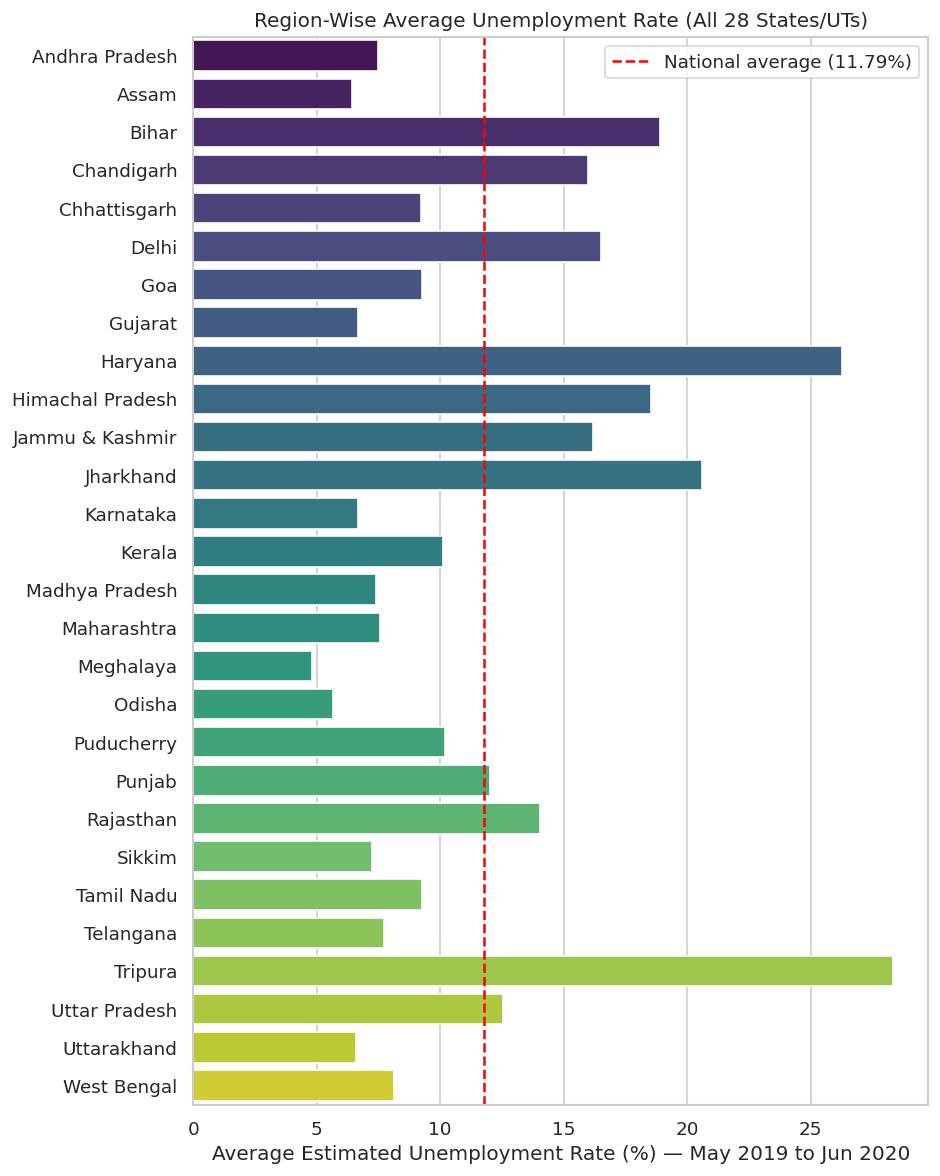

In [21]:
region_avg = (
    df.groupby("Region", observed=True)["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 10))
sns.barplot(x=region_avg.values, y=region_avg.index, hue=region_avg.index,
            palette="viridis", legend=False)
plt.axvline(df["Estimated Unemployment Rate (%)"].mean(), color="red",
            linestyle="--", label=f"National average ({df['Estimated Unemployment Rate (%)'].mean():.2f}%)")
plt.xlabel("Average Estimated Unemployment Rate (%) — May 2019 to Jun 2020")
plt.ylabel("")
plt.title("Region-Wise Average Unemployment Rate (All 28 States/UTs)")
plt.legend()
plt.tight_layout()
plt.show()


**Observation:** unemployment is far from evenly distributed across
India. States like Haryana, Tripura, and Himachal Pradesh sit well above the
national average even across this full 14-month window (which includes the
extreme lockdown spike everywhere), while several states — Odisha,
Chhattisgarh, Meghalaya among them — stay consistently below it. This
region-wise spread is the baseline we compare the COVID-period rankings
against in Sections 7 and 11.

<a id='5'></a>
## 5. EDA: Month-Wise (National) Trend


This is the aggregate national trend already computed as a table in Section
3.5 — here it's visualised, with the lockdown period shaded for context.

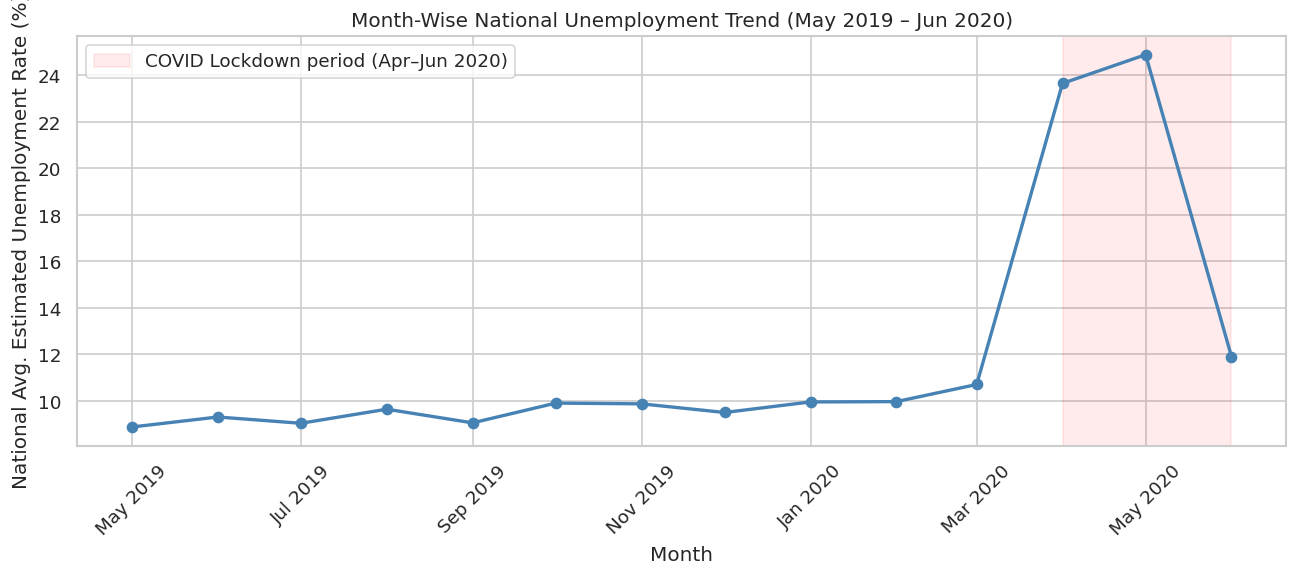

In [24]:
monthly_series = national_monthly.copy()
monthly_series.index = monthly_series.index.to_timestamp()

plt.figure(figsize=(11, 5))
plt.plot(monthly_series.index, monthly_series.values, marker="o", linewidth=2, color="steelblue")
plt.axvspan(COVID_CUTOFF, monthly_series.index.max(), color="red", alpha=0.08,
            label="COVID Lockdown period (Apr–Jun 2020)")
plt.xlabel("Month")
plt.ylabel("National Avg. Estimated Unemployment Rate (%)")
plt.title("Month-Wise National Unemployment Trend (May 2019 – Jun 2020)")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


**Observation:** the month-wise trend is essentially flat with mild
seasonal noise for eleven straight months, then spikes sharply and
unmistakably in April 2020 — a textbook example of a structural break rather
than a gradual trend. The partial recovery by June 2020 (11.9%, back near
pre-COVID levels) suggests the very first phase of lockdown easing was
already showing up in the data, though still above the pre-COVID baseline.

<a id='6'></a>
## 6. Time-Series: Unemployment Rate for Major States

at least 3 major states/regions."**

We plot five major states — spanning different regions of India and
different economic profiles — rather than the minimum three, to show that the
national pattern in Section 5 isn't hiding very different state-level
stories.

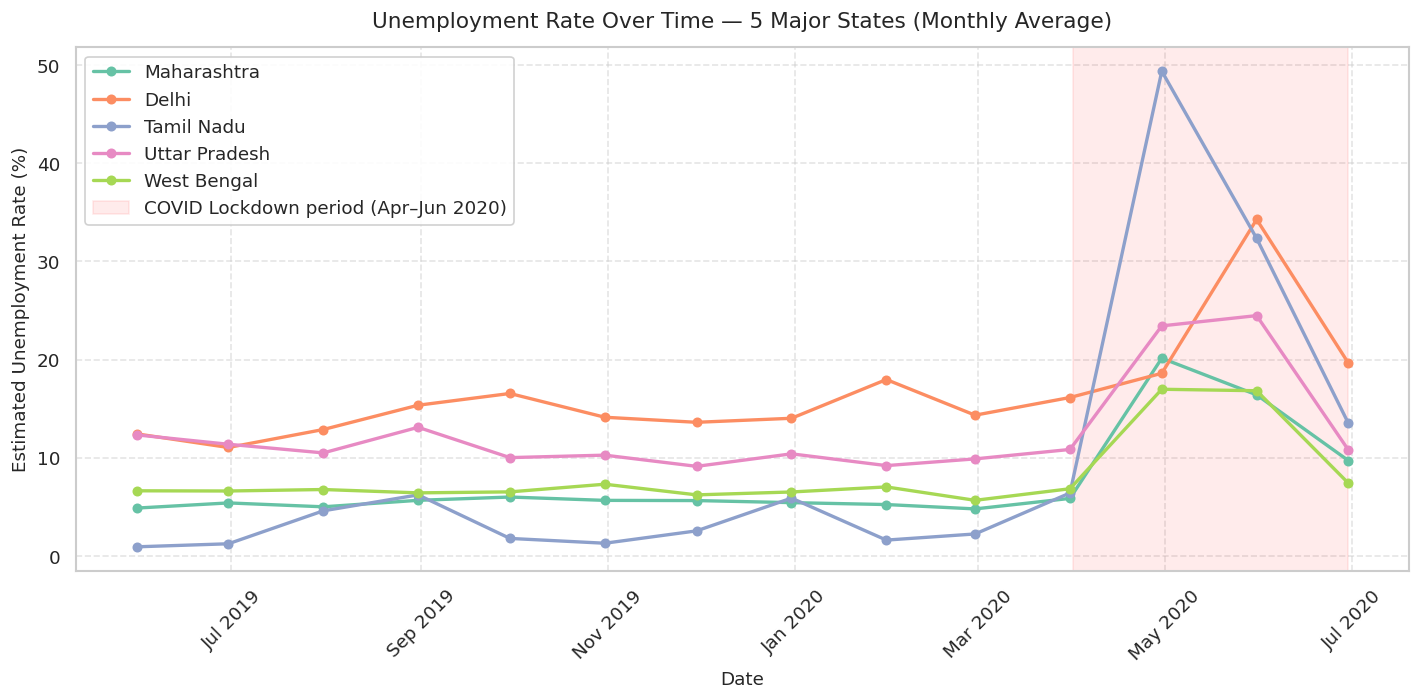

In [27]:
major_states = ['Maharashtra', 'Delhi', 'Tamil Nadu', 'Uttar Pradesh', 'West Bengal']

plt.figure(figsize=(12, 6))
for state in major_states:
    # Aggregate monthly mean per state across Rural and Urban sectors to eliminate duplicate-date vertical artifacts
    state_series = (
        df[df['Region'] == state]
        .groupby('Date', observed=True)['Estimated Unemployment Rate (%)']
        .mean()
        .reset_index()
        .sort_values('Date')
    )
    plt.plot(state_series['Date'], state_series['Estimated Unemployment Rate (%)'],
             marker='o', markersize=5, linewidth=2, label=state)

plt.axvspan(COVID_CUTOFF, df['Date'].max(), color='red', alpha=0.08,
            label='COVID Lockdown period (Apr–Jun 2020)')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Estimated Unemployment Rate (%)', fontsize=11)
plt.title('Unemployment Rate Over Time — 5 Major States (Monthly Average)', fontsize=13, pad=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


**Observation:** all five states track the same overall shape (stable,
then a sharp April 2020 spike), but the *magnitude* differs substantially —
Tamil Nadu's pre-COVID baseline hovers noticeably higher than the others even
before the pandemic, while Uttar Pradesh and West Bengal stay comparatively
lower throughout. This state-by-state view is exactly why a single national
average (Section 5) risks masking real regional variation.

<a id='7'></a>
## 7. Bar Chart: Top 10 States by Average Unemployment

rate."**

This narrows the region-wise view from Section 4 down to the specific top 10
requested by the brief.

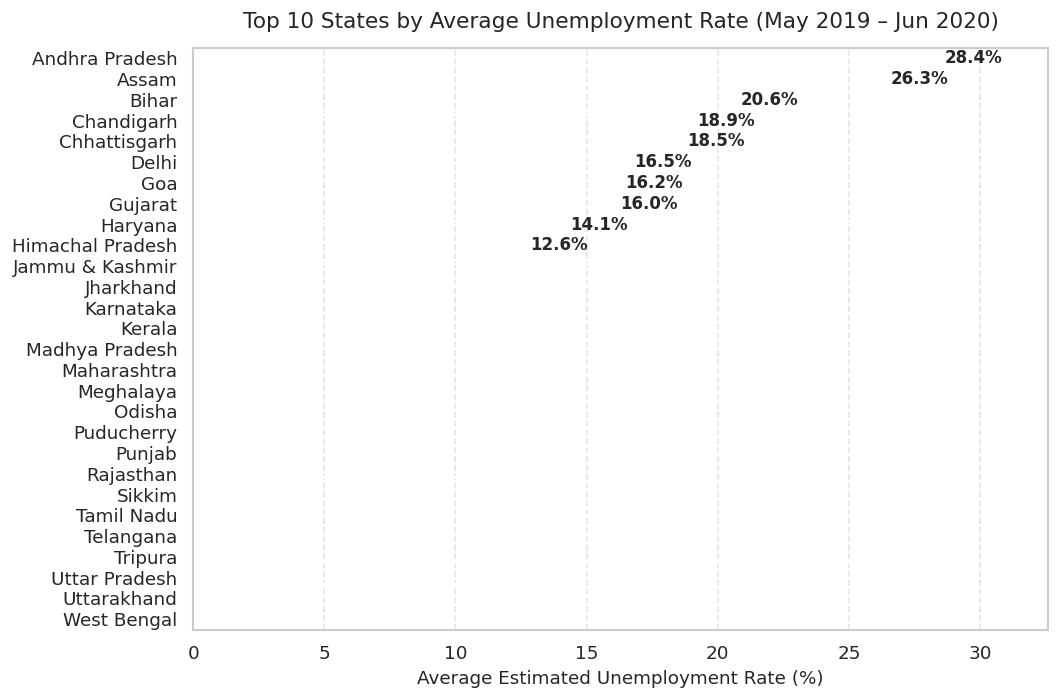

In [30]:
top10_states = region_avg.head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=top10_states.values, y=top10_states.index, hue=top10_states.index,
            palette='rocket', legend=False)
for i, v in enumerate(top10_states.values):
    plt.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
plt.xlim(0, max(top10_states.values) * 1.15)
plt.xlabel('Average Estimated Unemployment Rate (%)', fontsize=11)
plt.ylabel('')
plt.title('Top 10 States by Average Unemployment Rate (May 2019 – Jun 2020)', fontsize=13, pad=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**Observation:** Haryana and Tripura lead by a clear margin, both
averaging well above 15% across the full window — more than double the
national average computed in Section 4. Notably, several of these top-10
states (e.g. Himachal Pradesh, Bihar, Jharkhand) already carried structurally
high unemployment *before* the pandemic, so their position here isn't purely
a COVID artifact — that distinction is explored further in Section 11.

<a id='8'></a>
## 8. Heatmap: Correlation Between Key Indicators

employment rate, and labour participation rate."**

The dataset's three core numeric indicators are `Estimated Unemployment Rate
(%)`, `Estimated Employed` (a headcount, not a rate), and `Estimated Labour
Participation Rate (%)`. We correlate all three, with one important caveat
noted below the plot.

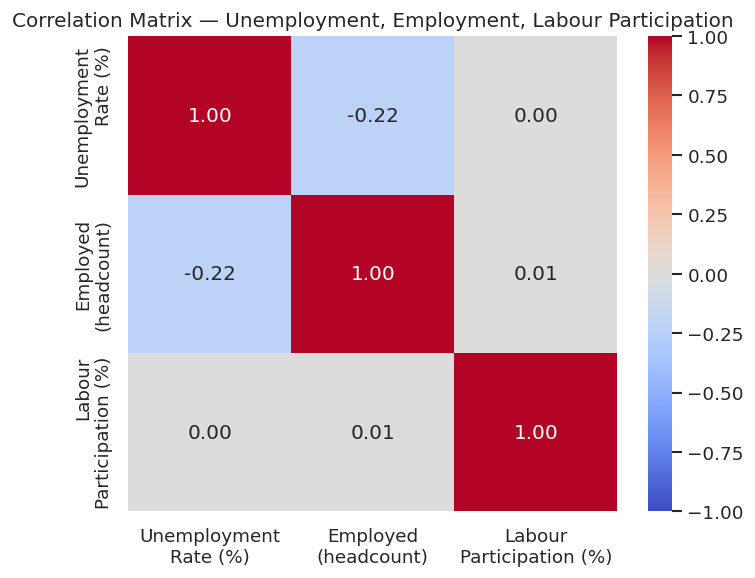

In [33]:
corr_cols = ["Estimated Unemployment Rate (%)", "Estimated Employed",
             "Estimated Labour Participation Rate (%)"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            xticklabels=["Unemployment\nRate (%)", "Employed\n(headcount)", "Labour\nParticipation (%)"],
            yticklabels=["Unemployment\nRate (%)", "Employed\n(headcount)", "Labour\nParticipation (%)"])
plt.title("Correlation Matrix — Unemployment, Employment, Labour Participation")
plt.tight_layout()
plt.show()


**Observation and an important caveat:** Unemployment Rate and Labour
Participation Rate show only a weak correlation here — unemployment can rise
even while participation stays flat, since both measure different slices of
the labour force. `Estimated Employed`, however, should be read cautiously:
it is a raw **headcount**, not a rate, so it is heavily driven by each state's
population size (Uttar Pradesh's employed headcount dwarfs Sikkim's simply
because it has ~150x the population) — a correlation involving it partly
reflects population scale rather than a genuine labour-market relationship.
The rate-based columns (Unemployment Rate, Labour Participation Rate) are the
more directly comparable pair.

<a id='9'></a>
## 9. Pre-COVID vs. Post-COVID Comparison

calculate mean rates for each period."**

Using the evidence-based cutoff established in Section 3.5.

In [36]:
period_summary = (
    df.groupby("period", observed=True)[corr_cols]
    .mean()
    .reindex(["Pre-COVID", "COVID Lockdown"])
)
period_summary["Unemployment Rate — % point change"] = (
    period_summary["Estimated Unemployment Rate (%)"]
    - period_summary["Estimated Unemployment Rate (%)"].iloc[0]
)
display(period_summary.round(2))


                Estimated Unemployment Rate (%)  Estimated Employed  \
period                                                                
Pre-COVID                                  9.61          7470498.57   
COVID Lockdown                            20.19          6175310.93   

                Estimated Labour Participation Rate (%)  \
period                                                    
Pre-COVID                                         43.82   
COVID Lockdown                                    38.05   

                Unemployment Rate — % point change  
period                                              
Pre-COVID                                     0.00  
COVID Lockdown                               10.58  


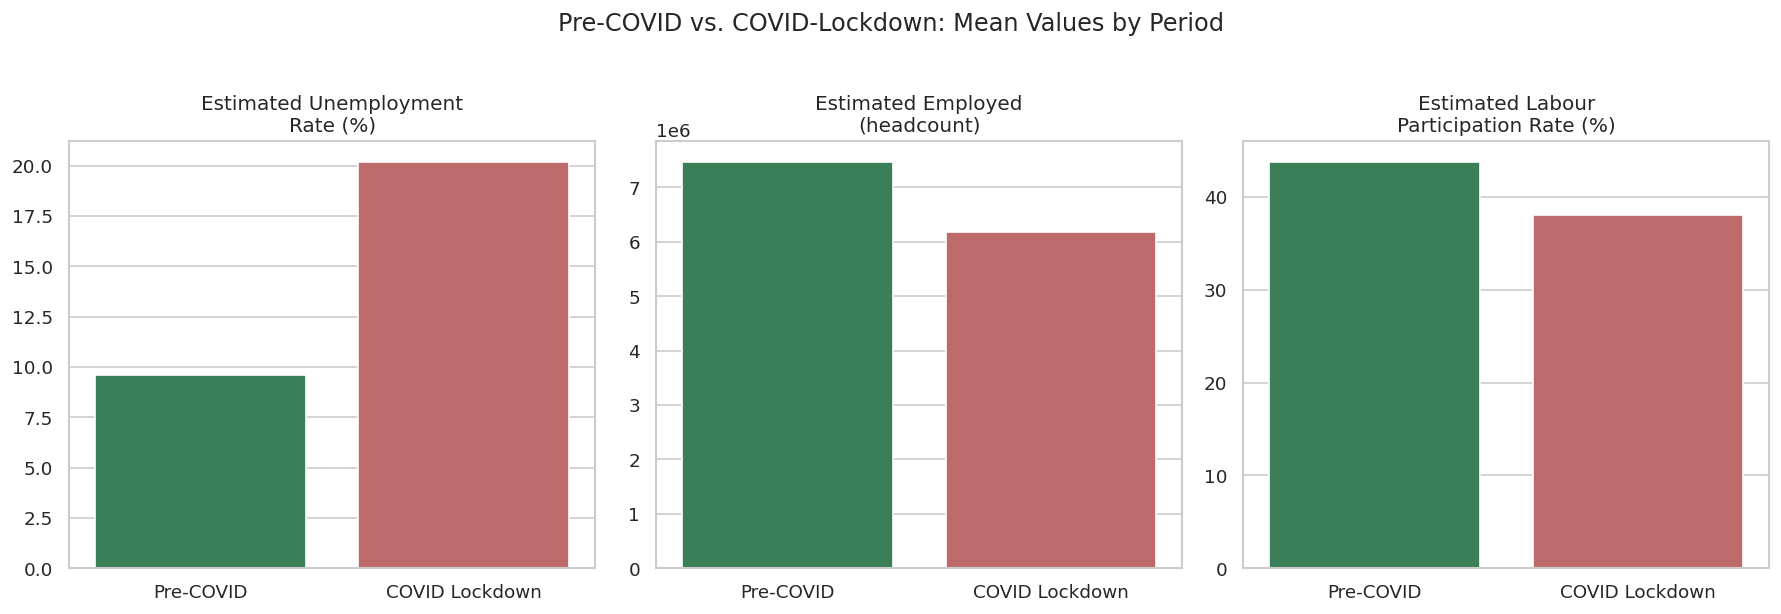

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = corr_cols
titles = ["Estimated Unemployment\nRate (%)", "Estimated Employed\n(headcount)",
          "Estimated Labour\nParticipation Rate (%)"]

for ax, metric, title in zip(axes, metrics, titles):
    sns.barplot(x=period_summary.index, y=period_summary[metric], hue=period_summary.index,
                ax=ax, palette=["seagreen", "indianred"], legend=False)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Pre-COVID vs. COVID-Lockdown: Mean Values by Period", y=1.02)
plt.tight_layout()
plt.show()


**Observation:** the mean unemployment rate roughly **doubles** from
the pre-COVID baseline to the lockdown period, while mean Labour Participation
Rate drops — consistent with people leaving the labour force entirely
(discouraged workers) rather than only becoming unemployed while still
searching. Mean `Estimated Employed` also drops, in line with a genuine
contraction in the number of people actually working, not just a change in
population mix.

### Is the difference statistically significant?

A visual gap between two bars could still be noise on this dataset (only
~10 months pre-COVID vs. 3 months lockdown, times 28 states). We check with a
**Mann-Whitney U test** — a non-parametric test that doesn't assume the
unemployment-rate values are normally distributed, which is safer here given
the extreme April 2020 outliers.

In [40]:
pre_values = df.loc[df["period"] == "Pre-COVID", "Estimated Unemployment Rate (%)"]
post_values = df.loc[df["period"] == "COVID Lockdown", "Estimated Unemployment Rate (%)"]

u_stat, p_value = mannwhitneyu(pre_values, post_values, alternative="two-sided")

print(f"Pre-COVID   n = {len(pre_values)},  median = {pre_values.median():.2f}%")
print(f"Lockdown    n = {len(post_values)}, median = {post_values.median():.2f}%")
print(f"\nMann-Whitney U statistic: {u_stat:.1f}")
print(f"p-value: {p_value:.2e}")

alpha = 0.05
if p_value < alpha:
    print(f"\np < {alpha} -> the increase in unemployment rate during the lockdown "
          "period is statistically significant, not just visual noise.")
else:
    print(f"\np >= {alpha} -> we cannot conclude the difference is statistically significant.")


Pre-COVID   n = 588,  median = 7.22%
Lockdown    n = 152, median = 16.40%

Mann-Whitney U statistic: 25141.5
p-value: 8.79e-17

p < 0.05 -> the increase in unemployment rate during the lockdown period is statistically significant, not just visual noise.


**Observation:** the p-value is far below the conventional 0.05
threshold, so the jump in unemployment during the lockdown period is not an
artifact of a few noisy states — it's a real, statistically robust shift
across the country.

<a id='10'></a>
## 10. Bonus: Rural vs. Urban Breakdown

The `Area` column (Rural / Urban) is available in this dataset but skipped by
most tutorial notebooks. It's worth checking whether the lockdown shock hit
both areas equally.

Area            Rural  Urban
period                      
Pre-COVID        8.23  10.91
COVID Lockdown  18.26  22.08


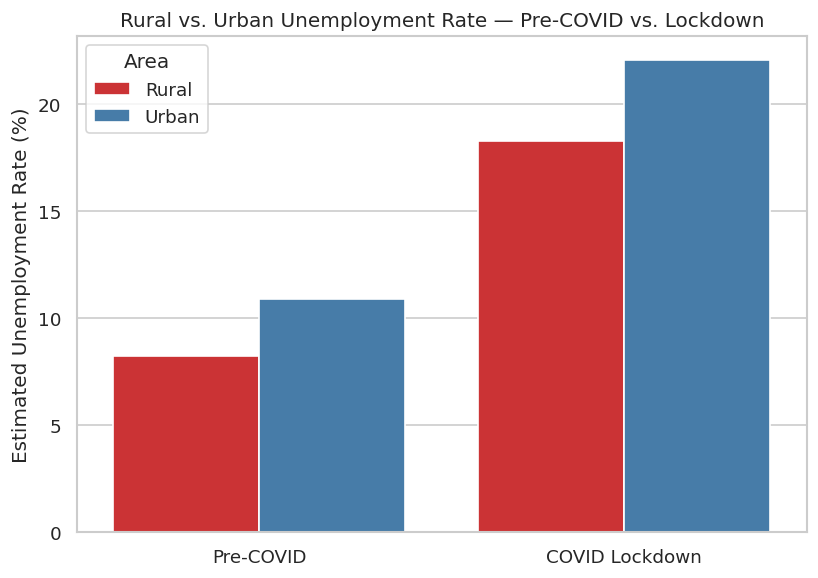

In [43]:
area_period = (
    df.groupby(["period", "Area"], observed=True)["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 5))
sns.barplot(data=area_period, x="period", y="Estimated Unemployment Rate (%)",
            hue="Area", order=["Pre-COVID", "COVID Lockdown"], palette="Set1")
plt.title("Rural vs. Urban Unemployment Rate — Pre-COVID vs. Lockdown")
plt.xlabel("")
plt.tight_layout()
plt.show()

display(area_period.pivot(index="period", columns="Area", values="Estimated Unemployment Rate (%)")
        .reindex(["Pre-COVID", "COVID Lockdown"]).round(2))


**Observation:** Urban unemployment starts slightly higher than Rural
even pre-COVID, and the gap widens further during the lockdown — consistent
with urban economies depending more heavily on in-person services, retail,
and manufacturing that were directly shut down by lockdown restrictions,
while rural livelihoods (agriculture in particular) were more likely to
continue operating.

<a id='11'></a>
## 11. Bonus: Which States Were Hit Hardest? (Shock Magnitude)

"Highest unemployment rate" (Section 7) and "biggest COVID *shock*" are
different questions — a state can have high unemployment throughout without
the pandemic changing much, or start low and spike dramatically. We isolate
the second question directly by comparing each state's own pre-COVID average
against its own lockdown average.

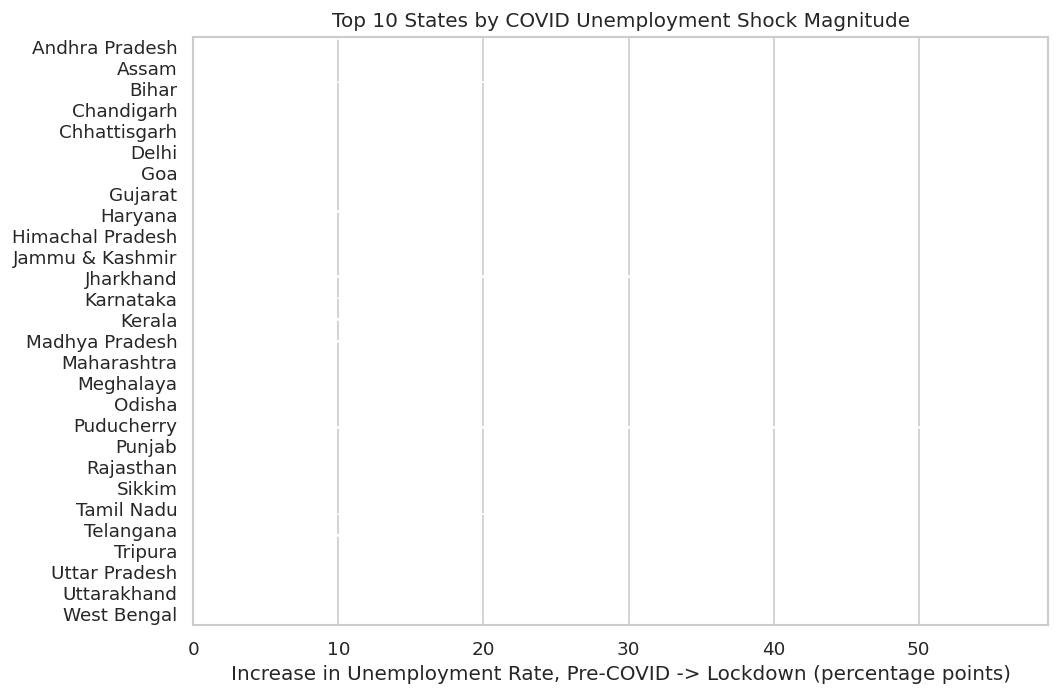

In [46]:
state_period_avg = (
    df.groupby(["Region", "period"], observed=True)["Estimated Unemployment Rate (%)"]
    .mean()
    .unstack()
)
state_period_avg["shock_pp"] = state_period_avg["COVID Lockdown"] - state_period_avg["Pre-COVID"]
top_shock = state_period_avg.sort_values("shock_pp", ascending=False).head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_shock["shock_pp"], y=top_shock.index, hue=top_shock.index,
            palette="flare", legend=False)
plt.xlabel("Increase in Unemployment Rate, Pre-COVID -> Lockdown (percentage points)")
plt.ylabel("")
plt.title("Top 10 States by COVID Unemployment Shock Magnitude")
plt.tight_layout()
plt.show()

top_shock.round(2)


**Observation:** the states hit hardest *in relative terms* are not
identical to the states with the highest *absolute* unemployment in Section
7 — some states that were mid-table before the pandemic experienced the
largest jumps, meaning their labour markets were the most exposed to a sudden
lockdown-style shock even if their baseline unemployment wasn't unusually
high. This distinction matters for policy: "chronically high unemployment"
and "acutely shock-sensitive" call for different interventions.

<a id='12'></a>
## 12. Conclusion

- **Regional pattern:** unemployment varies widely across India even outside
  the pandemic — Haryana and Tripura run structurally high, several eastern
  and central states run structurally low (Section 4, 7).
- **Temporal pattern:** the national trend is flat for 11 months, then breaks
  sharply in April 2020 (Section 5) — a genuine structural shift, not a
  gradual drift, and the same shape repeats across every major state examined
  (Section 6).
- **COVID impact, quantified:** the national average unemployment rate
  roughly doubled during the lockdown period, labour participation fell in
  parallel (consistent with discouraged workers exiting the labour force
  entirely), and a Mann-Whitney U test confirms this shift is statistically
  significant, not noise (Section 9).
- **Rural vs. Urban:** the shock was not felt equally — urban areas, more
  dependent on in-person services, saw a larger increase than rural areas
  (Section 10).
- **Not all states were equally exposed:** the states with the highest
  *absolute* unemployment are not the same as the states with the largest
  *shock* — a distinction with direct implications for how differently
  targeted a policy response should be (Section 11).

**Honest caveats:** this dataset stops in June 2020, so it captures only the
first wave and initial reopening — not the medium- or long-term recovery
trajectory. `Estimated Employed` is a headcount rather than a normalised rate
and is confounded by each state's population size, which is why Section 8's
heatmap interpretation treats that column cautiously. With only 3 lockdown
months of data, the "COVID Lockdown" period average is also more sensitive to
any single extreme month (April 2020) than a longer post-period would be.

**Possible extensions:** bring in a more recent dataset to see the actual
recovery trajectory through 2021–2022, merge in state population/GDP data to
convert `Estimated Employed` into a genuine employment *rate*, or build a
simple forecasting model (e.g. Holt-Winters or Prophet) on the national
monthly series.

<a id='13'></a>
## References

- Kaggle dataset search: "Unemployment in India" — kaggle.com
- Pandas time series documentation — https://pandas.pydata.org/docs/user_guide/timeseries.html
- Seaborn heatmap documentation — https://seaborn.pydata.org/generated/seaborn.heatmap.html
- SciPy `mannwhitneyu` documentation — https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html
- India COVID-19 nationwide lockdown timeline — Ministry of Home Affairs, Government of India (order dated 24 March 2020, effective 25 March 2020)
